In [2]:
import os
import shutil
import zipfile


zip_file_name = "/content/dataset_ancient_modern (1).zip"

extraction_dir = "./ancient_dataset"
dataset_segregated_dir = "./dataset_segregated"

# Final two class folders
ancient_class_name = "Ancient_Non_OBC"
modern_class_name = "Modern_Kanji"

# Image extensions
image_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif", ".webp")

print("1. Cleaning old memory space...")

if os.path.exists(extraction_dir):
    shutil.rmtree(extraction_dir)

if os.path.exists(dataset_segregated_dir):
    shutil.rmtree(dataset_segregated_dir)

print("2. Unzipping uploaded data...")

with zipfile.ZipFile(zip_file_name, "r") as zip_ref:
    zip_ref.extractall(extraction_dir)

print("   -> Extraction completed.")

print("3. Creating Ancient and Modern folders...")

ancient_output_dir = os.path.join(dataset_segregated_dir, ancient_class_name)
modern_output_dir = os.path.join(dataset_segregated_dir, modern_class_name)

os.makedirs(ancient_output_dir, exist_ok=True)
os.makedirs(modern_output_dir, exist_ok=True)

print("4. Collecting images from available two classes...")

ancient_count = 0
modern_count = 0

for root, dirs, files in os.walk(extraction_dir):

    root_parts = root.replace("\\", "/").split("/")

    for file in files:

        if not file.lower().endswith(image_extensions):
            continue

        source_path = os.path.join(root, file)

        # -------------------------------
        # Ancient class
        # -------------------------------
        if ancient_class_name in root_parts:
            new_name = f"ancient_{ancient_count:06d}_{file}"
            destination_path = os.path.join(ancient_output_dir, new_name)

            shutil.copy(source_path, destination_path)
            ancient_count += 1

        # -------------------------------
        # Modern class
        # -------------------------------
        elif modern_class_name in root_parts:
            new_name = f"modern_{modern_count:06d}_{file}"
            destination_path = os.path.join(modern_output_dir, new_name)

            shutil.copy(source_path, destination_path)
            modern_count += 1

print("Final dataset structure:")
print("dataset_segregated/")
print(f"   {ancient_class_name}/")
print(f"      {ancient_count} images")
print(f"   {modern_class_name}/")
print(f"      {modern_count} images")



1. Cleaning old memory space...
2. Unzipping uploaded data...


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset_ancient_modern (1).zip'

In [ ]:
!pip install pennylane

Ancient images found: 1762
Modern images found : 1762

Raw dataset shape: (3524, 256)
Ancient label -1 count: 1762
Modern label +1 count : 1762

--- VISUAL PROOF: Ancient vs Modern ---


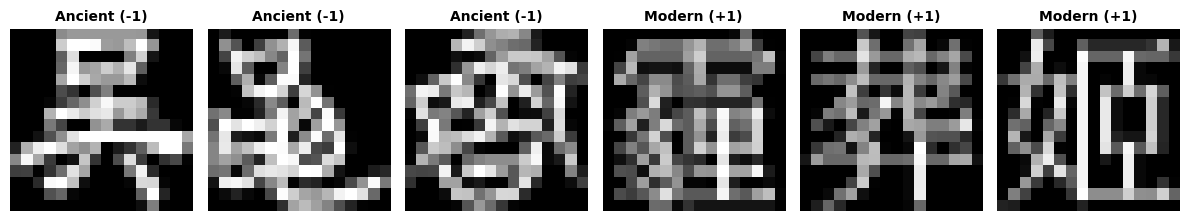


--- Applying PCA to compress 256 pixels into 16 features... ---
Explained variance ratio sum: 0.3436082

Ancient vs Modern features extracted and ready for Quantum Embedding.
X_train shape: (2819, 16)
X_test shape : (705, 16)
y_train shape: (2819,)
y_test shape : (705,)


In [ ]:
%matplotlib inline
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from pennylane import numpy as pnp

ancient_folder = "./dataset_segregated/Ancient_Non_OBC"
modern_folder  = "./dataset_segregated/Modern_Kanji"

def collect_image_paths(folder):
    image_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp")
    image_paths = []

    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(image_extensions):
                image_paths.append(os.path.join(root, f))

    return sorted(image_paths)


def load_pca_dataset_and_show(ancient_folder, modern_folder, target_size=(16, 16)):
    X_raw, y = [], []

    ancient_paths = collect_image_paths(ancient_folder)
    modern_paths = collect_image_paths(modern_folder)

    print("Ancient images found:", len(ancient_paths))
    print("Modern images found :", len(modern_paths))

    if len(ancient_paths) == 0:
        raise ValueError("No ancient images found. Check Ancient_Non_OBC folder path.")

    if len(modern_paths) == 0:
        raise ValueError("No modern images found. Check Modern_Kanji folder path.")


    # Ancient images -> label -1

    for img_path in ancient_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
        img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

        # Invert: black strokes become bright values
        img_resized = 255 - img_resized

        X_raw.append(img_resized.flatten())
        y.append(-1)


    # Modern images -> label +1

    for img_path in modern_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
        img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

        # Invert: black strokes become bright values
        img_resized = 255 - img_resized

        X_raw.append(img_resized.flatten())
        y.append(1)

    X_raw = np.array(X_raw, dtype=np.float32)
    y = np.array(y)

    print("\nRaw dataset shape:", X_raw.shape)
    print("Ancient label -1 count:", np.sum(y == -1))
    print("Modern label +1 count :", np.sum(y == 1))


    # VISUALIZATION


    plt.figure(figsize=(12, 3))
    print("\n--- VISUAL PROOF: Ancient vs Modern ---")

    ancient_indices = np.where(y == -1)[0][:3]
    modern_indices = np.where(y == 1)[0][:3]

    display_indices = np.concatenate([ancient_indices, modern_indices])

    for i, idx in enumerate(display_indices):
        plt.subplot(1, 6, i + 1)
        plt.imshow(X_raw[idx].reshape(16, 16), cmap="gray")

        label = "Ancient (-1)" if y[idx] == -1 else "Modern (+1)"
        plt.title(label, fontsize=10, fontweight="bold")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


    # Train-test split BEFORE PCA to avoid data leakage


    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )


    # PCA: Compress 256 pixels into 16 quantum features


    print("\n--- Applying PCA to compress 256 pixels into 16 features... ---")

    pca = PCA(n_components=16)

    X_train_pca = pca.fit_transform(X_train_raw)
    X_test_pca = pca.transform(X_test_raw)

    print("Explained variance ratio sum:", np.sum(pca.explained_variance_ratio_))


    # Scaling to [0, pi] for quantum angle embedding


    scaler = MinMaxScaler(feature_range=(0, np.pi))

    X_train_scaled = scaler.fit_transform(X_train_pca)
    X_test_scaled = scaler.transform(X_test_pca)

    return X_train_scaled, X_test_scaled, y_train, y_test

# RUN MODIFIED LOADER

X_train, X_test, y_train, y_test = load_pca_dataset_and_show(
    ancient_folder,
    modern_folder
)


X_train = pnp.array(X_train, requires_grad=False)
X_test  = pnp.array(X_test, requires_grad=False)

y_train = pnp.array(y_train, requires_grad=False)
y_test  = pnp.array(y_test, requires_grad=False)

print("\nAncient vs Modern features extracted and ready for Quantum Embedding.")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

Using lightning.qubit backend.

--- Training QCNN for Ancient vs Modern Classification ---
Iteration  10 | Training Loss: 0.7936
Iteration  20 | Training Loss: 0.9839
Iteration  30 | Training Loss: 0.8620
Iteration  40 | Training Loss: 0.9451
Iteration  50 | Training Loss: 0.9017
Iteration  60 | Training Loss: 0.7864
Iteration  70 | Training Loss: 0.7967
Iteration  80 | Training Loss: 0.7877
Iteration  90 | Training Loss: 0.8845
Iteration 100 | Training Loss: 0.8345

 Training completed.

--- Extracting Final Predictions ---

FINAL QCNN TEST METRICS
Accuracy  : 72.91%
Precision : 0.6731
Recall    : 0.8892
F1-score  : 0.7662
ROC-AUC   : 0.7955

Classification Report:
                 precision    recall  f1-score   support

Ancient_Non_OBC       0.84      0.57      0.68       353
   Modern_Kanji       0.67      0.89      0.77       352

       accuracy                           0.73       705
      macro avg       0.76      0.73      0.72       705
   weighted avg       0.76      0.73  

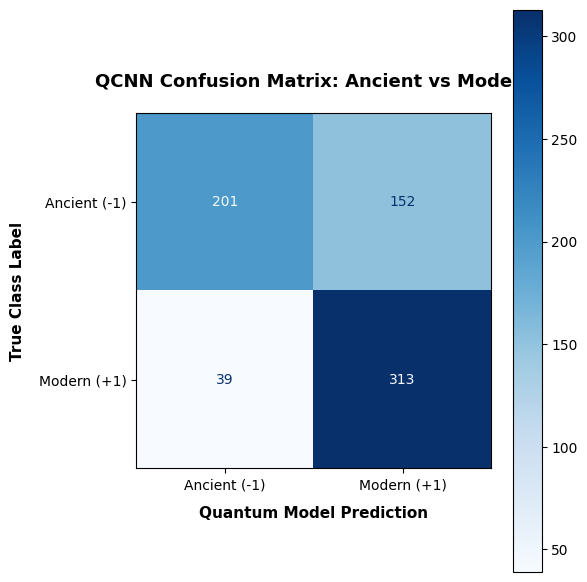

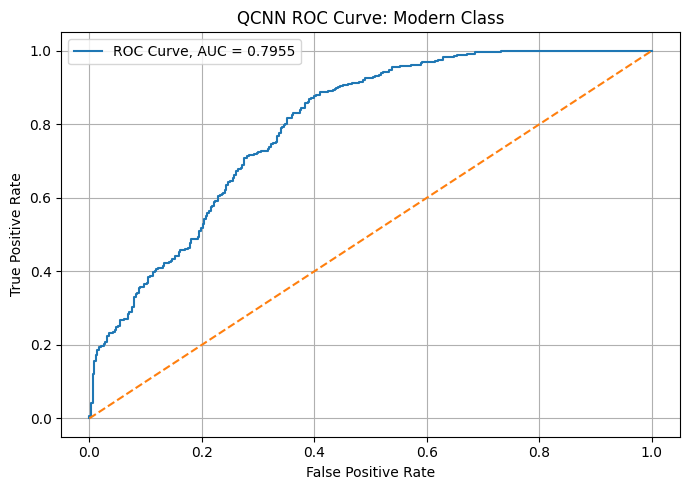

In [ ]:


import pennylane as qml
from pennylane import numpy as pnp

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    roc_curve
)

# 1. QUANTUM DEVICE


try:
    dev = qml.device("lightning.qubit", wires=16)
    print("Using lightning.qubit backend.")
except Exception:
    dev = qml.device("default.qubit", wires=16)
    print("lightning.qubit not available. Using default.qubit backend.")

# 2. QUANTUM ARCHITECTURE


def conv_layer(w, wires):
    qml.RY(w[0], wires=wires[0])
    qml.RY(w[1], wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])


def pool_layer(w, wires):
    qml.CRZ(w[0], wires=[wires[0], wires[1]])
    qml.PauliX(wires=wires[1])
    qml.CRX(w[1], wires=[wires[0], wires[1]])


@qml.qnode(dev, interface="autograd")
def qcnn_circuit(weights, x):

    # 16 PCA features -> 16 qubits
    qml.AngleEmbedding(x, wires=range(16), rotation="Y")

    # Layer 1: 16 -> 8 scale
    for i in range(0, 16, 2):
        conv_layer(weights[0:2], wires=[i, i + 1])

    for i in range(0, 16, 2):
        pool_layer(weights[2:4], wires=[i, i + 1])

    # Layer 2: 8 -> 4 scale
    w2 = [0, 2, 4, 6, 8, 10, 12, 14]

    for i in range(0, 8, 2):
        conv_layer(weights[4:6], wires=[w2[i], w2[i + 1]])

    for i in range(0, 8, 2):
        pool_layer(weights[6:8], wires=[w2[i], w2[i + 1]])

    # Layer 3: 4 -> 2 scale
    w3 = [0, 4, 8, 12]

    for i in range(0, 4, 2):
        conv_layer(weights[8:10], wires=[w3[i], w3[i + 1]])

    for i in range(0, 4, 2):
        pool_layer(weights[10:12], wires=[w3[i], w3[i + 1]])

    # Layer 4: 2 -> 1 scale
    w4 = [0, 8]

    conv_layer(weights[12:14], wires=[w4[0], w4[1]])
    pool_layer(weights[14:16], wires=[w4[0], w4[1]])

    # Output expectation value in [-1, +1]
    return qml.expval(qml.PauliZ(0))

# 3. LOSS FUNCTION


def cost(weights, x_batch, y_batch):
    preds = [qcnn_circuit(weights, x) for x in x_batch]
    preds = pnp.array(preds)

    return pnp.mean((pnp.array(y_batch) - preds) ** 2)

# 4. TRAINING

weights = pnp.array(
    0.05 * np.random.randn(16),
    requires_grad=True
)

opt = qml.AdamOptimizer(stepsize=0.05)

batch_size = 64
iterations = 100

loss_history = []

print("\n--- Training QCNN for Ancient vs Modern Classification ---")

for it in range(iterations):

    idx = np.random.randint(0, len(X_train), size=batch_size)

    xb = X_train[idx]
    yb = y_train[idx]

    weights = opt.step(lambda w: cost(w, xb, yb), weights)

    if (it + 1) % 10 == 0:
        current_loss = cost(weights, xb, yb)
        loss_history.append(float(current_loss))

        print(
            f"Iteration {it + 1:3d} | "
            f"Training Loss: {current_loss:.4f}"
        )

print("\n Training completed.")

# 5. FINAL PREDICTIONS

print("\n--- Extracting Final Predictions ---")

raw_predictions = np.array(
    [qcnn_circuit(weights, x) for x in X_test],
    dtype=float
)

preds = np.where(raw_predictions >= 0, 1, -1)

prob_modern = (raw_predictions + 1) / 2


# 6. METRICS


accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds, pos_label=1)
recall = recall_score(y_test, preds, pos_label=1)
f1 = f1_score(y_test, preds, pos_label=1)

try:
    auc = roc_auc_score((np.array(y_test) == 1).astype(int), prob_modern)
except Exception:
    auc = None

print("\n==============================")
print("FINAL QCNN TEST METRICS")
print("==============================")
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

if auc is not None:
    print(f"ROC-AUC   : {auc:.4f}")
else:
    print("ROC-AUC   : Not available")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        preds,
        labels=[-1, 1],
        target_names=["Ancient_Non_OBC", "Modern_Kanji"]
    )
)

# 7. CONFUSION MATRIX


matrix_data = confusion_matrix(
    y_test,
    preds,
    labels=[-1, 1]
)

display_labels = [
    "Ancient (-1)",
    "Modern (+1)"
]

visual_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix_data,
    display_labels=display_labels
)

fig, ax = plt.subplots(figsize=(6, 6))

visual_matrix.plot(
    cmap=plt.cm.Blues,
    values_format="d",
    ax=ax
)

plt.title(
    "QCNN Confusion Matrix: Ancient vs Modern",
    fontsize=13,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Quantum Model Prediction",
    fontsize=11,
    fontweight="bold",
    labelpad=10
)

plt.ylabel(
    "True Class Label",
    fontsize=11,
    fontweight="bold",
    labelpad=10
)

plt.grid(False)
plt.tight_layout()
plt.show()

# 8. ROC CURVE

if auc is not None:
    y_test_binary = (np.array(y_test) == 1).astype(int)

    fpr, tpr, thresholds = roc_curve(
        y_test_binary,
        prob_modern
    )

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"ROC Curve, AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("QCNN ROC Curve: Modern Class")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


--- GENERATING QUANTUM CIRCUIT DIAGRAM ---


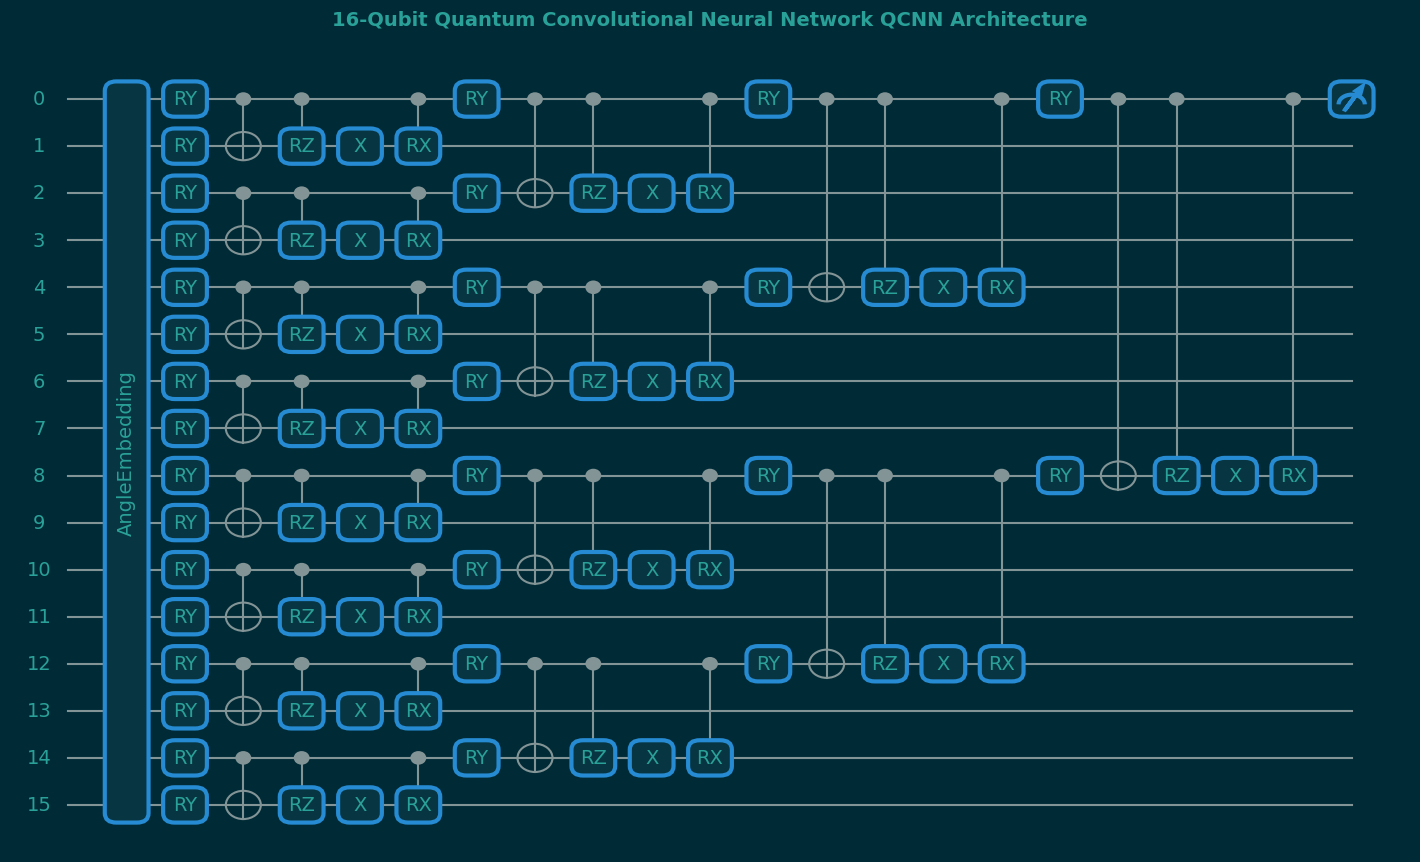

In [ ]:

# 10. QUANTUM CIRCUIT DIAGRAM

print("--- GENERATING QUANTUM CIRCUIT DIAGRAM ---")

dummy_sample = np.zeros(16)

fig, ax = qml.draw_mpl(qcnn_circuit, style="solarized_dark")(
    weights,
    dummy_sample
)

fig.set_size_inches(14, 8)

plt.title(
    "16-Qubit Quantum Convolutional Neural Network QCNN Architecture",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.show()